In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             average_precision_score, f1_score,
                             precision_recall_curve, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
X_train_f = pd.read_csv('../data/processed/X_train_fraud.csv')
X_test_f  = pd.read_csv('../data/processed/X_test_fraud.csv')
y_train_f = pd.read_csv('../data/processed/y_train_fraud.csv').squeeze()
y_test_f  = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()

print("Fraud Data:")
print("X_train shape:", X_train_f.shape)
print("X_test shape:", X_test_f.shape)
print("y_train distribution:\n", y_train_f.value_counts())

Fraud Data:
X_train shape: (219136, 194)
X_test shape: (30223, 194)
y_train distribution:
 class
0    109568
1    109568
Name: count, dtype: int64


In [3]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-PR:    {auc_pr:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit','Fraud'],
                yticklabels=['Legit','Fraud'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../data/processed/cm_{name.replace(" ","_")}.png')
    plt.show()
    
    return {'model': name, 'F1': f1, 'AUC-PR': auc_pr}


Model: Logistic Regression (Fraud)
F1 Score:  0.3035
AUC-PR:    0.3600

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.72      0.82     27393
           1       0.20      0.66      0.30      2830

    accuracy                           0.71     30223
   macro avg       0.58      0.69      0.56     30223
weighted avg       0.88      0.71      0.77     30223



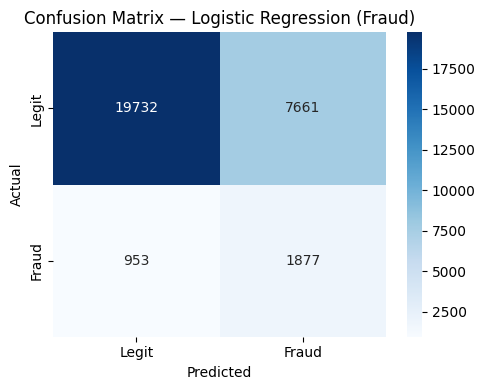

In [4]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_f, y_train_f)

lr_results = evaluate_model("Logistic Regression (Fraud)", lr, X_test_f, y_test_f)


Model: Random Forest (Fraud)
F1 Score:  0.6825
AUC-PR:    0.6228

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.98      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.97      0.76      0.83     30223
weighted avg       0.96      0.95      0.95     30223



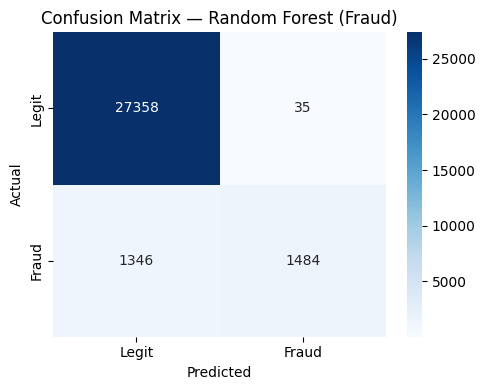

In [5]:
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train_f, y_train_f)

rf_results = evaluate_model("Random Forest (Fraud)", rf, X_test_f, y_test_f)


Model: XGBoost (Fraud)
F1 Score:  0.6775
AUC-PR:    0.6029

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     27393
           1       0.96      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.95      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223



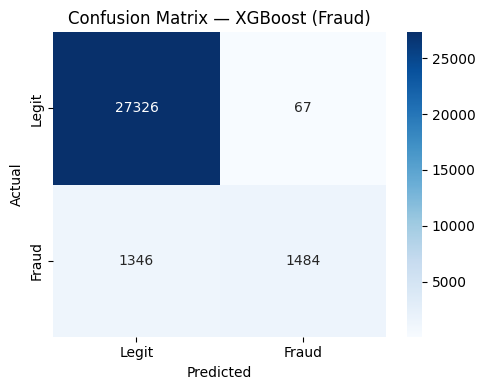

In [6]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train_f, y_train_f)

xgb_results = evaluate_model("XGBoost (Fraud)", xgb, X_test_f, y_test_f)


=== MODEL COMPARISON (Fraud Data) ===
                      model       F1   AUC-PR
      Random Forest (Fraud) 0.682456 0.622811
            XGBoost (Fraud) 0.677471 0.602866
Logistic Regression (Fraud) 0.303525 0.359995


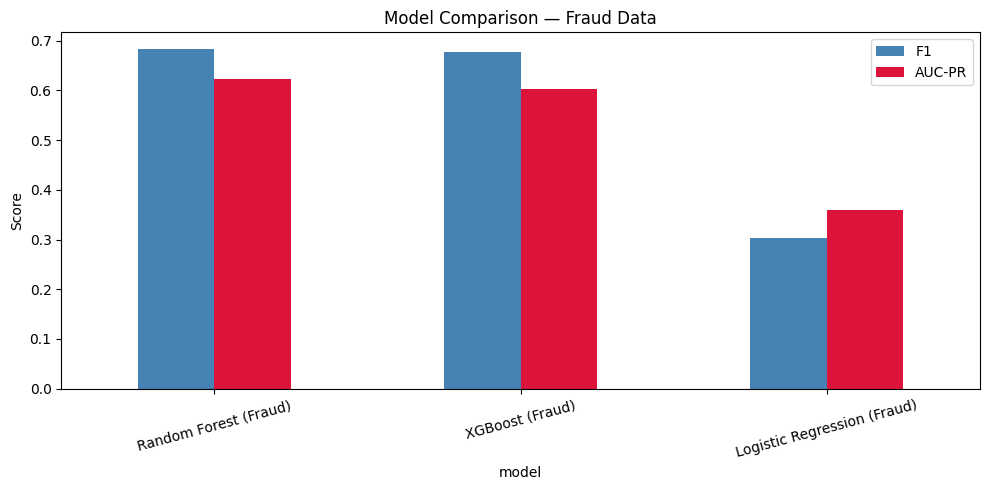

In [7]:
results_df = pd.DataFrame([lr_results, rf_results, xgb_results])
results_df = results_df.sort_values('AUC-PR', ascending=False)

print("\n=== MODEL COMPARISON (Fraud Data) ===")
print(results_df.to_string(index=False))

results_df.set_index('model')[['F1', 'AUC-PR']].plot(
    kind='bar', figsize=(10, 5), color=['steelblue', 'crimson']
)
plt.title('Model Comparison — Fraud Data')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_fraud.png')
plt.show()

In [8]:
import os
os.makedirs('../models', exist_ok=True)

# Save all three
joblib.dump(lr, '../models/lr_fraud.pkl')
joblib.dump(rf, '../models/rf_fraud.pkl')
joblib.dump(xgb, '../models/xgb_fraud.pkl')

print("Models saved!")

Models saved!


In [9]:
X_train_cc = pd.read_csv('../data/processed/X_train_cc.csv')
X_test_cc  = pd.read_csv('../data/processed/X_test_cc.csv')
y_train_cc = pd.read_csv('../data/processed/y_train_cc.csv').squeeze()
y_test_cc  = pd.read_csv('../data/processed/y_test_cc.csv').squeeze()

print("Credit Card Data:")
print("X_train shape:", X_train_cc.shape)
print("X_test shape:", X_test_cc.shape)
print("y_train distribution:\n", y_train_cc.value_counts())

Credit Card Data:
X_train shape: (454902, 30)
X_test shape: (56962, 30)
y_train distribution:
 Class
0    227451
1    227451
Name: count, dtype: int64



Model: Logistic Regression (CC)
F1 Score:  0.1094
AUC-PR:    0.7249

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



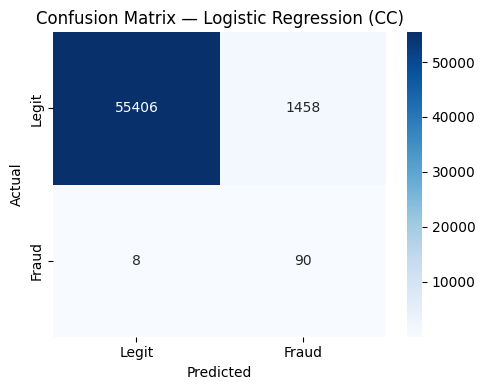

In [10]:
lr_cc = LogisticRegression(max_iter=1000, random_state=42)
lr_cc.fit(X_train_cc, y_train_cc)

lr_cc_results = evaluate_model("Logistic Regression (CC)", lr_cc, X_test_cc, y_test_cc)


Model: Random Forest (CC)
F1 Score:  0.5608
AUC-PR:    0.7964

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.42      0.85      0.56        98

    accuracy                           1.00     56962
   macro avg       0.71      0.92      0.78     56962
weighted avg       1.00      1.00      1.00     56962



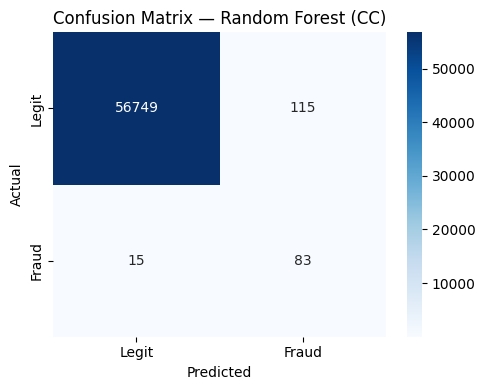

In [11]:
rf_cc = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_cc.fit(X_train_cc, y_train_cc)

rf_cc_results = evaluate_model("Random Forest (CC)", rf_cc, X_test_cc, y_test_cc)


Model: XGBoost (CC)
F1 Score:  0.4942
AUC-PR:    0.8270

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962



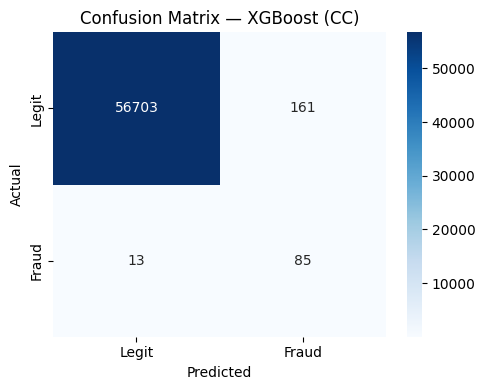

In [12]:
xgb_cc = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_cc.fit(X_train_cc, y_train_cc)

xgb_cc_results = evaluate_model("XGBoost (CC)", xgb_cc, X_test_cc, y_test_cc)


=== MODEL COMPARISON (Credit Card Data) ===
                   model       F1   AUC-PR
            XGBoost (CC) 0.494186 0.827005
      Random Forest (CC) 0.560811 0.796397
Logistic Regression (CC) 0.109356 0.724861


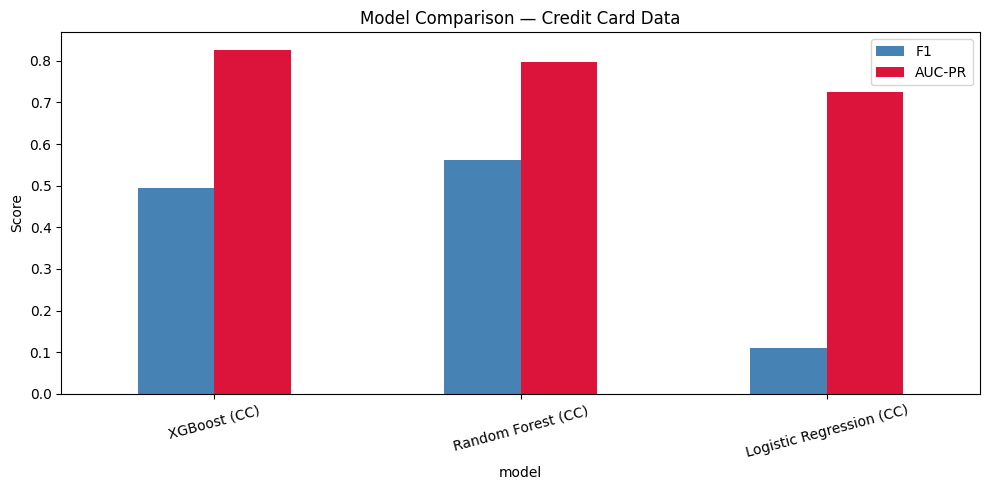

In [13]:
cc_results_df = pd.DataFrame([lr_cc_results, rf_cc_results, xgb_cc_results])
cc_results_df = cc_results_df.sort_values('AUC-PR', ascending=False)

print("\n=== MODEL COMPARISON (Credit Card Data) ===")
print(cc_results_df.to_string(index=False))

cc_results_df.set_index('model')[['F1', 'AUC-PR']].plot(
    kind='bar', figsize=(10, 5), color=['steelblue', 'crimson']
)
plt.title('Model Comparison — Credit Card Data')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_cc.png')
plt.show()

In [14]:
joblib.dump(lr_cc, '../models/lr_cc.pkl')
joblib.dump(rf_cc, '../models/rf_cc.pkl')
joblib.dump(xgb_cc, '../models/xgb_cc.pkl')

print("All credit card models saved!")

All credit card models saved!
